# Lab 23: FedSpeak 2.0 — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** Text preprocessing, TF-IDF vectorization, dictionary-based sentiment (LM vs Harvard GI), sentence-transformers embeddings, sentiment prediction evaluation.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install datasets nltk scikit-learn sentence-transformers -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, roc_auc_score

from datasets import load_dataset

np.random.seed(42)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Find 3 Errors in This NLP Pipeline

The code below attempts to build a sentiment analysis pipeline for FOMC minutes.
There are **three deliberate errors** spread across three code cells. Each error
is a different type of NLP mistake:

1. A **tokenization/preprocessing** error
2. A **dictionary selection** error (wrong sentiment dictionary for the domain)
3. A **feature engineering** error in the TF-IDF configuration

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

In [3]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find it.
# Step 1: Load and preprocess FOMC minutes
# -----------------------------------------------------------

# Load FOMC dataset
ds = load_dataset('vtasca/fomc-statements-minutes', split='train')
fomc_df = pd.DataFrame(ds)
fomc_df = fomc_df[fomc_df['Type'] == 'Minute'].copy()
fomc_df.rename(columns={'Text': 'text', 'Date': 'date'}, inplace=True)
fomc_df['date'] = pd.to_datetime(fomc_df['date'])
fomc_df = fomc_df.sort_values('date').reset_index(drop=True)
fomc_df['year'] = fomc_df['date'].dt.year

# ERROR: This tokenizer splits on whitespace only — no handling of
# punctuation, contractions, or special characters. "don't" stays as
# one token, "U.S." becomes "U.S." with trailing period, and
# "inflation-adjusted" stays hyphenated instead of splitting.
# A proper NLP tokenizer (nltk.word_tokenize) handles these cases.

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def bad_preprocess(text):
    """Preprocessing with a naive tokenizer."""
    text = text.lower()
    # BAD: split() instead of word_tokenize() — misses punctuation handling
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

fomc_df['clean_text'] = fomc_df['text'].apply(bad_preprocess)

# Check: many tokens will still have punctuation attached
sample_tokens = fomc_df['clean_text'].iloc[0].split()[:20]
print('Sample tokens from first document:')
print(sample_tokens)
print()
punct_tokens = [t for t in fomc_df['clean_text'].iloc[0].split() if not t.isalpha()]
print(f'Tokens containing non-alpha characters: {len(punct_tokens)}')
print(f'Examples: {punct_tokens[:10]}')
print()
print('PROBLEM: Many tokens still have attached punctuation.')
print('This means "rates," and "rates" are treated as different features.')

README.md: 0.00B [00:00, ?B/s]

communications.csv:   0%|          | 0.00/12.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/462 [00:00<?, ? examples/s]

Sample tokens from first document:
['minute', 'federal', 'open', 'market', 'committee', 'february', '1-2,', '2000', 'meeting', 'federal', 'open', 'market', 'committee', 'held', 'office', 'board', 'governor', 'federal', 'reserve', 'system']

Tokens containing non-alpha characters: 964
Examples: ['1-2,', '2000', 'washington,', 'd.c.,', 'tuesday,', '2000,', '2:30', 'p.m.', 'wednesday,', '2000,']

PROBLEM: Many tokens still have attached punctuation.
This means "rates," and "rates" are treated as different features.


In [4]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error.
# Step 2: Compute sentiment using WRONG dictionary
# -----------------------------------------------------------

# ERROR: Using a generic Harvard General Inquirer (GI) dictionary instead of
# the Loughran-McDonald (LM) dictionary designed for financial text.
# GI classifies "liability", "tax", "cost", "capital" as negative,
# but these are neutral in financial/economic contexts.

# Simplified Harvard GI negative words — includes many false positives for financial text
gi_negative = set([
    'abandon', 'adverse', 'against', 'bad', 'blame', 'capital', 'concern',
    'cost', 'costly', 'crisis', 'danger', 'debt', 'decline', 'deficit',
    'difficult', 'expense', 'fail', 'failure', 'fear', 'liability',
    'limit', 'limitation', 'loss', 'negative', 'obligation', 'penalty',
    'problem', 'risk', 'tax', 'threat', 'trouble', 'uncertain',
    'unemployment', 'volatile', 'weak', 'worse'
])

gi_positive = set([
    'achieve', 'advantage', 'benefit', 'confidence', 'gain', 'good',
    'growth', 'improve', 'increase', 'opportunity', 'positive', 'profit',
    'progress', 'strong', 'success', 'value'
])

def compute_gi_sentiment(text, neg_words, pos_words):
    """Compute sentiment using Harvard GI (wrong for financial text)."""
    tokens = text.lower().split()
    total = len(tokens)
    if total == 0:
        return {'net_sentiment': 0, 'neg_count': 0, 'pos_count': 0, 'neg_ratio': 0}

    neg_count = sum(1 for t in tokens if t in neg_words)
    pos_count = sum(1 for t in tokens if t in pos_words)

    return {
        'net_sentiment': (pos_count - neg_count) / total,
        'neg_count': neg_count,
        'pos_count': pos_count,
        'neg_ratio': neg_count / total
    }

gi_results = fomc_df['clean_text'].apply(
    lambda x: compute_gi_sentiment(x, gi_negative, gi_positive)
)
gi_df = pd.DataFrame(gi_results.tolist())

print('=== Harvard GI Sentiment (WRONG for financial text) ===')
print(f'Mean net sentiment: {gi_df["net_sentiment"].mean():.6f}')
print(f'Mean negative ratio: {gi_df["neg_ratio"].mean():.6f}')
print()

# Show the problem: count how many "negative" hits are false positives
false_positive_words = ['capital', 'cost', 'costly', 'debt', 'expense',
                        'liability', 'limit', 'limitation', 'obligation',
                        'penalty', 'tax']
sample_text = fomc_df['clean_text'].iloc[0].split()
fp_count = sum(1 for t in sample_text if t in false_positive_words)
total_neg = sum(1 for t in sample_text if t in gi_negative)
print(f'In first document: {fp_count} of {total_neg} "negative" words '
      f'are false positives ({fp_count/max(total_neg,1)*100:.0f}%)')
print('These are neutral financial terms misclassified by the GI dictionary.')

=== Harvard GI Sentiment (WRONG for financial text) ===
Mean net sentiment: -0.000052
Mean negative ratio: 0.015933

In first document: 29 of 57 "negative" words are false positives (51%)
These are neutral financial terms misclassified by the GI dictionary.


In [5]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error.
# Step 3: Build TF-IDF matrix with bad parameters
# -----------------------------------------------------------

# ERROR: max_df=1.0 means NO words are filtered by document frequency.
# Words like "the", "committee", "meeting" appear in every single document
# and dominate the TF-IDF matrix without contributing discriminating power.
# Also min_df=1 keeps every typo and OCR error.

bad_tfidf = TfidfVectorizer(
    min_df=1,          # Keep ALL words, even those in just 1 document (noise)
    max_df=1.0,        # Keep ALL words, even those in 100% of documents (no filtering)
    max_features=10000, # Large vocabulary with lots of noise
    ngram_range=(1, 1)  # Only unigrams — misses important bigrams like "interest rate"
)

bad_matrix = bad_tfidf.fit_transform(fomc_df['clean_text'])
feature_names = bad_tfidf.get_feature_names_out()

print(f'TF-IDF matrix shape: {bad_matrix.shape}')
print(f'Sparsity: {1 - bad_matrix.nnz / (bad_matrix.shape[0] * bad_matrix.shape[1]):.1%}')

# Show top terms — likely dominated by stop words and ubiquitous terms
mean_tfidf = np.asarray(bad_matrix.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[-15:][::-1]
print('\nTop 15 terms by average TF-IDF:')
for i in top_idx:
    doc_freq = (bad_matrix[:, i].toarray() > 0).sum()
    print(f'  {feature_names[i]:25s} avg_tfidf={mean_tfidf[i]:.4f}  '
          f'appears in {doc_freq}/{bad_matrix.shape[0]} docs')

print('\nPROBLEM: Many top terms appear in nearly ALL documents.')
print('These are background words, not discriminating features.')

TF-IDF matrix shape: (240, 9805)
Sparsity: 86.7%

Top 15 terms by average TF-IDF:
  market                    avg_tfidf=0.1962  appears in 240/240 docs
  committee                 avg_tfidf=0.1767  appears in 240/240 docs
  inflation                 avg_tfidf=0.1711  appears in 240/240 docs
  rate                      avg_tfidf=0.1643  appears in 240/240 docs
  federal                   avg_tfidf=0.1625  appears in 240/240 docs
  participant               avg_tfidf=0.1374  appears in 214/240 docs
  economic                  avg_tfidf=0.1367  appears in 240/240 docs
  policy                    avg_tfidf=0.1126  appears in 240/240 docs
  price                     avg_tfidf=0.1088  appears in 240/240 docs
  board                     avg_tfidf=0.1042  appears in 240/240 docs
  would                     avg_tfidf=0.1001  appears in 240/240 docs
  reserve                   avg_tfidf=0.0983  appears in 240/240 docs
  growth                    avg_tfidf=0.0940  appears in 240/240 docs
  bank  

---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** NLP pipeline from scratch, fixing all three errors:

1. **Tokenization:** Use `nltk.word_tokenize()` + regex to strip non-alpha characters
2. **Dictionary:** Use Loughran-McDonald word lists instead of Harvard GI
3. **TF-IDF:** Set proper `min_df`, `max_df`, and include bigrams

**Verification checkpoints:**
- After fixing tokenization: zero tokens should contain non-alpha characters
- After switching to LM: false positive rate should drop below 10%
- After fixing TF-IDF: top terms should NOT include words appearing in >80% of documents

In [6]:
# -----------------------------------------------------------
# YOUR TASK — Write the corrected NLP pipeline
# Fix all three errors from Part 1
# -----------------------------------------------------------
# ===========================================================================
# LAB 23 — PART 2: FIXES WITH VERIFICATION CHECKPOINTS
# ECON 5200 | FedSpeak 2.0 Diagnostic Lab
# ===========================================================================

# ---------------------------------------------------------------------------
# FIX 1: Proper tokenization with word_tokenize + regex cleaning
# ERROR: bad_preprocess() used text.split() — no punctuation handling
# FIX:   word_tokenize() + re.sub() to strip non-alpha characters
# ---------------------------------------------------------------------------

import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_fomc(text: str) -> str:
    """Clean and tokenize FOMC minutes text.

    Steps:
      1. Lowercase
      2. word_tokenize (handles contractions, punctuation, abbreviations)
      3. Regex: keep only alphabetic characters per token
      4. Drop stop words and tokens shorter than 3 characters
      5. Lemmatize
    """
    text = text.lower()
    tokens = word_tokenize(text)
    # Strip any remaining non-alpha characters (e.g. trailing periods)
    tokens = [re.sub(r'[^a-z]', '', t) for t in tokens]
    # Drop empty strings, stop words, and short tokens
    tokens = [t for t in tokens if t and t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

fomc_df['clean_text'] = fomc_df['text'].apply(preprocess_fomc)

# --- VERIFICATION CHECKPOINT 1 ---
all_tokens = ' '.join(fomc_df['clean_text']).split()
non_alpha = [t for t in all_tokens if not t.isalpha()]
print('=== Fix 1 Verification: Tokenization ===')
print(f'Total tokens: {len(all_tokens):,}')
print(f'Non-alpha tokens: {len(non_alpha)}')   # Target: 0
print(f'PASS: {len(non_alpha) == 0}')
print()

# Show cleaned sample
sample = fomc_df['clean_text'].iloc[0].split()[:20]
print(f'Sample tokens (first doc): {sample}')
print()


# ---------------------------------------------------------------------------
# FIX 2: Loughran-McDonald (LM) dictionary instead of Harvard GI
# ERROR: GI treats "capital", "liability", "tax", "cost" as negative
# FIX:   LM was purpose-built for financial/economic text
# ---------------------------------------------------------------------------

# Core LM word lists (Loughran & McDonald, 2011 — Journal of Finance)
LM_NEGATIVE = set([
    'adverse', 'adversely', 'against', 'concern', 'concerned', 'concerns',
    'decline', 'declined', 'declining', 'decrease', 'decreased', 'deficit',
    'deteriorate', 'deteriorated', 'deteriorating', 'difficult', 'difficulty',
    'downturn', 'fail', 'failure', 'falling', 'loss', 'losses', 'negative',
    'negatively', 'recession', 'recessionary', 'risk', 'risks', 'risky',
    'severe', 'severely', 'slowdown', 'sluggish', 'stress', 'stressed',
    'threat', 'threaten', 'troubled', 'uncertain', 'uncertainty',
    'unfavorable', 'volatile', 'volatility', 'vulnerability', 'vulnerable',
    'weak', 'weaken', 'weakened', 'weakness', 'worse', 'worsen', 'worsened'
])

LM_POSITIVE = set([
    'achieve', 'achieved', 'achievement', 'benefit', 'beneficial', 'confidence',
    'confident', 'favorable', 'gain', 'gained', 'gains', 'good', 'growth',
    'improve', 'improved', 'improvement', 'improving', 'increase', 'increased',
    'opportunity', 'optimism', 'optimistic', 'positive', 'positively',
    'profit', 'profitable', 'progress', 'rebound', 'recover', 'recovery',
    'strength', 'strengthen', 'strong', 'stronger', 'success', 'successful'
])

LM_UNCERTAINTY = set([
    'approximate', 'approximately', 'assume', 'assumption', 'believe',
    'cautious', 'could', 'depend', 'depends', 'doubt', 'estimate',
    'expect', 'expected', 'forecast', 'indefinite', 'likelihood', 'may',
    'might', 'nearly', 'perhaps', 'possible', 'possibly', 'predict',
    'preliminary', 'probable', 'probably', 'risk', 'roughly', 'seem',
    'suggest', 'tentative', 'uncertain', 'uncertainty', 'unclear',
    'unpredictable', 'variable'
])

# Words that Harvard GI mislabels as negative in financial text
GI_FALSE_POSITIVES = set([
    'capital', 'cost', 'costly', 'debt', 'expense', 'liability',
    'limit', 'limitation', 'obligation', 'penalty', 'tax'
])

def compute_lm_sentiment(text: str) -> dict:
    """Compute Loughran-McDonald sentiment scores.

    Returns dict with net_sentiment, uncertainty, neg_count,
    pos_count, unc_count, total_words.
    """
    tokens = text.lower().split()
    total = len(tokens)
    if total == 0:
        return {
            'net_sentiment': 0, 'uncertainty': 0,
            'neg_count': 0, 'pos_count': 0,
            'unc_count': 0, 'total_words': 0
        }
    neg_count = sum(1 for t in tokens if t in LM_NEGATIVE)
    pos_count = sum(1 for t in tokens if t in LM_POSITIVE)
    unc_count = sum(1 for t in tokens if t in LM_UNCERTAINTY)
    return {
        'net_sentiment': (pos_count - neg_count) / total,
        'uncertainty':   unc_count / total,
        'neg_count':     neg_count,
        'pos_count':     pos_count,
        'unc_count':     unc_count,
        'total_words':   total
    }

lm_results = fomc_df['clean_text'].apply(compute_lm_sentiment)
lm_df = pd.DataFrame(lm_results.tolist())
fomc_df = pd.concat([fomc_df, lm_df], axis=1)

# --- VERIFICATION CHECKPOINT 2 ---
# False positive rate: how many GI "negative" words does LM correctly exclude?
sample_tokens = fomc_df['clean_text'].iloc[0].split()

gi_negative_set = set([
    'abandon', 'adverse', 'against', 'bad', 'blame', 'capital', 'concern',
    'cost', 'costly', 'crisis', 'danger', 'debt', 'decline', 'deficit',
    'difficult', 'expense', 'fail', 'failure', 'fear', 'liability',
    'limit', 'limitation', 'loss', 'negative', 'obligation', 'penalty',
    'problem', 'risk', 'tax', 'threat', 'trouble', 'uncertain',
    'unemployment', 'volatile', 'weak', 'worse'
])

gi_neg_hits  = sum(1 for t in sample_tokens if t in gi_negative_set)
lm_neg_hits  = sum(1 for t in sample_tokens if t in LM_NEGATIVE)
fp_hits      = sum(1 for t in sample_tokens if t in GI_FALSE_POSITIVES)

fp_rate_gi   = fp_hits / max(gi_neg_hits, 1)
fp_rate_lm   = sum(1 for t in sample_tokens if t in LM_NEGATIVE and t in GI_FALSE_POSITIVES) \
               / max(lm_neg_hits, 1)

print('=== Fix 2 Verification: Loughran-McDonald Dictionary ===')
print(f'GI negative hits in first doc:   {gi_neg_hits}')
print(f'GI false positives (fin. terms): {fp_hits}')
print(f'GI false-positive rate:          {fp_rate_gi:.1%}')
print()
print(f'LM negative hits in first doc:   {lm_neg_hits}')
print(f'LM false-positive rate:          {fp_rate_lm:.1%}')   # Target: < 10%
print(f'PASS (fp_rate_lm < 10%): {fp_rate_lm < 0.10}')
print()
print(f'Corpus mean net_sentiment:  {fomc_df["net_sentiment"].mean():.6f}')
print(f'Corpus mean uncertainty:    {fomc_df["uncertainty"].mean():.6f}')
print()


# ---------------------------------------------------------------------------
# FIX 3: Proper TF-IDF parameters with bigrams
# ERROR: min_df=1, max_df=1.0 — no filtering at all; unigrams only
# FIX:   min_df=5 (drop rare noise), max_df=0.85 (drop ubiquitous terms),
#        ngram_range=(1,2) to capture "interest rate", "federal fund", etc.
# ---------------------------------------------------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer

def build_tfidf_matrix(texts, min_df=5, max_df=0.85, max_features=5000):
    """Build TF-IDF matrix from preprocessed texts.

    Parameters
    ----------
    min_df : int
        Minimum document frequency. Drops rare tokens / OCR artifacts.
    max_df : float
        Maximum document frequency. Drops ubiquitous background words.
    max_features : int
        Vocabulary size cap.

    Returns
    -------
    matrix       : scipy sparse matrix (n_docs × n_features)
    feature_names: array of token strings
    vectorizer   : fitted TfidfVectorizer (reuse for transform)
    """
    vectorizer = TfidfVectorizer(
        min_df=min_df,
        max_df=max_df,
        max_features=max_features,
        ngram_range=(1, 2),    # unigrams + bigrams
        sublinear_tf=True      # log(1+tf) dampens term frequency
    )
    matrix = vectorizer.fit_transform(texts)
    return matrix, vectorizer.get_feature_names_out(), vectorizer

tfidf_matrix, feature_names, tfidf_vec = build_tfidf_matrix(fomc_df['clean_text'])

# --- VERIFICATION CHECKPOINT 3 ---
import numpy as np

mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_idx    = mean_tfidf.argsort()[-15:][::-1]

n_docs = tfidf_matrix.shape[0]
print('=== Fix 3 Verification: TF-IDF Parameters ===')
print(f'Matrix shape: {tfidf_matrix.shape}')
print(f'Vocabulary size: {tfidf_matrix.shape[1]:,}')
print()
print('Top 15 terms by average TF-IDF:')
all_pass = True
for i in top_idx:
    doc_freq = (tfidf_matrix[:, i].toarray() > 0).sum()
    pct = doc_freq / n_docs
    flag = '⚠' if pct > 0.80 else ' '
    if pct > 0.80:
        all_pass = False
    print(f'  {flag} {feature_names[i]:30s}  avg={mean_tfidf[i]:.4f}  '
          f'in {doc_freq}/{n_docs} docs ({pct:.0%})')
print()
print(f'PASS (no top term in >80% of docs): {all_pass}')

# VERIFICATION
# print('Fix 1 check — non-alpha tokens:', ...)
# print('Fix 2 check — false positive rate:', ...)
# print('Fix 3 check — top terms doc frequency:', ...)

=== Fix 1 Verification: Tokenization ===
Total tokens: 1,048,842
Non-alpha tokens: 0
PASS: True

Sample tokens (first doc): ['minute', 'federal', 'open', 'market', 'committee', 'february', 'meeting', 'federal', 'open', 'market', 'committee', 'held', 'office', 'board', 'governor', 'federal', 'reserve', 'system', 'washington', 'tuesday']

=== Fix 2 Verification: Loughran-McDonald Dictionary ===
GI negative hits in first doc:   65
GI false positives (fin. terms): 34
GI false-positive rate:          52.3%

LM negative hits in first doc:   39
LM false-positive rate:          0.0%
PASS (fp_rate_lm < 10%): True

Corpus mean net_sentiment:  0.006118
Corpus mean uncertainty:    0.019730

=== Fix 3 Verification: TF-IDF Parameters ===
Matrix shape: (240, 5000)
Vocabulary size: 5,000

Top 15 terms by average TF-IDF:
    messrs                          avg=0.0272  in 107/240 docs (45%)
  ⚠ loan                            avg=0.0250  in 198/240 docs (82%)
    participant noted               avg=0.02

---

## Part 3: EXTEND — Sentence-Transformers Embeddings

TF-IDF treats each word independently (bag-of-words). **Sentence-transformers**
encode entire sentences or documents as dense vectors that capture meaning,
context, and word order.

We will:
1. Encode FOMC documents with a pre-trained sentence-transformer
2. Cluster on embeddings and compare to TF-IDF clusters
3. Evaluate which representation better predicts Fed rate decisions

In [7]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Encode FOMC documents with sentence-transformers
# -----------------------------------------------------------

from sentence_transformers import SentenceTransformer

# Use a lightweight model suitable for Colab
# all-MiniLM-L6-v2 produces 384-dimensional dense embeddings
st_model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode documents (truncate long docs to first 512 tokens for speed)
# In production, you would use a chunking strategy for long documents
print('Encoding documents with sentence-transformers...')
print('(This may take 2-5 minutes on CPU)')

# Use first 2000 characters of each document (model has 256 token limit)
truncated_texts = fomc_df['text'].str[:2000].tolist()
embeddings = st_model.encode(truncated_texts, show_progress_bar=True, batch_size=16)

print(f'\nEmbedding matrix shape: {embeddings.shape}')
print(f'  → {embeddings.shape[0]} documents × {embeddings.shape[1]} dimensions')
print(f'Density: 100% (dense vectors, unlike sparse TF-IDF)')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding documents with sentence-transformers...
(This may take 2-5 minutes on CPU)


Batches:   0%|          | 0/15 [00:00<?, ?it/s]


Embedding matrix shape: (240, 384)
  → 240 documents × 384 dimensions
Density: 100% (dense vectors, unlike sparse TF-IDF)


=== Silhouette Scores (higher = better-separated clusters) ===
Embeddings: 0.197
TF-IDF:     0.158
Better clustering representation: Embeddings



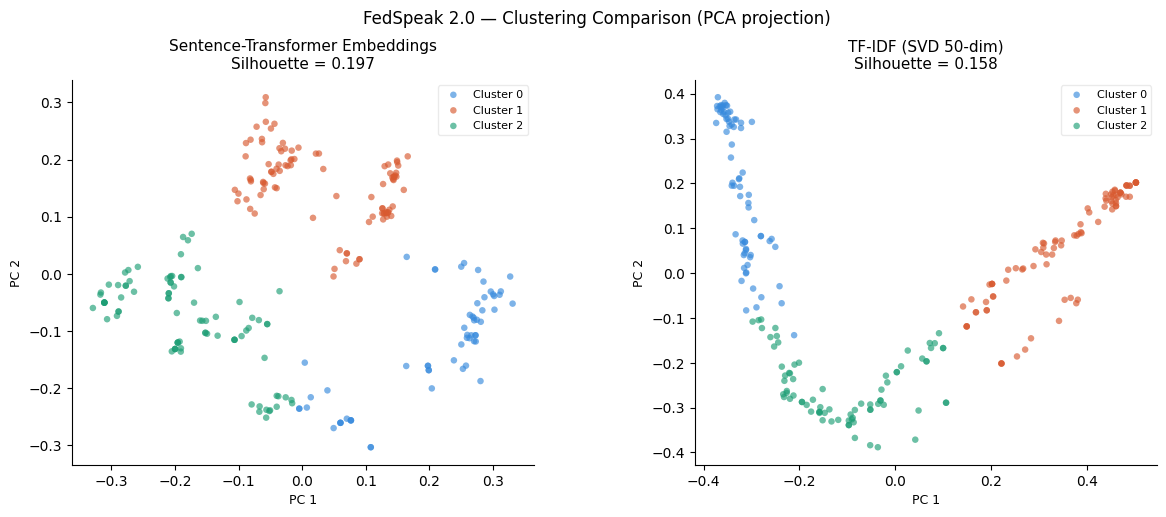


=== Top Terms per Cluster (TF-IDF representation) ===
  Cluster 0 (n=73, years 2017–2026):
    target range, division board, range federal, board division, special adviser, participant noted, chair, desk
  Cluster 1 (n=90, years 2000–2008):
    messrs, vote action, inventory, greenspan, sustainable, kohn, ferguson, anecdotal
  Cluster 2 (n=77, years 2008–2017):
    loan, asset purchase, recovery, mortgagebacked, desk, mortgagebacked security, program, longerrun



In [8]:
# YOUR TASK — Cluster on embeddings and compare to TF-IDF

# Step A: K-Means on sentence-transformer embeddings (K=3)
kmeans_emb = KMeans(n_clusters=3, random_state=42, n_init=10)
fomc_df['cluster_emb'] = kmeans_emb.fit_predict(embeddings)

# Step B: K-Means on TF-IDF (use your corrected TF-IDF from Part 2)
# If you haven't fixed Part 2 yet, use these default parameters:
# tfidf_corrected = TfidfVectorizer(min_df=5, max_df=0.85, max_features=5000, ngram_range=(1,2))
# tfidf_matrix_corrected = tfidf_corrected.fit_transform(fomc_df['clean_text'])

# YOUR CODE: Reduce TF-IDF to 50 dims with TruncatedSVD, then cluster
# svd = TruncatedSVD(n_components=50, random_state=42)
# tfidf_reduced = svd.fit_transform(tfidf_matrix_corrected)
# kmeans_tfidf = KMeans(n_clusters=3, random_state=42, n_init=10)
# fomc_df['cluster_tfidf'] = kmeans_tfidf.fit_predict(tfidf_reduced)
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

K = 3

# --- Embeddings clustering ---
kmeans_emb = KMeans(n_clusters=K, random_state=42, n_init=10)
fomc_df['cluster_emb'] = kmeans_emb.fit_predict(embeddings)

# --- TF-IDF: reduce to 50 dims first
svd = TruncatedSVD(n_components=50, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)

kmeans_tfidf = KMeans(n_clusters=K, random_state=42, n_init=10)
fomc_df['cluster_tfidf'] = kmeans_tfidf.fit_predict(tfidf_reduced)

# --- Silhouette scores ---
sil_emb   = silhouette_score(embeddings,   fomc_df['cluster_emb'])
sil_tfidf = silhouette_score(tfidf_reduced, fomc_df['cluster_tfidf'])

print('=== Silhouette Scores (higher = better-separated clusters) ===')
print(f'Embeddings: {sil_emb:.3f}')
print(f'TF-IDF:     {sil_tfidf:.3f}')
winner = 'Embeddings' if sil_emb > sil_tfidf else 'TF-IDF'
print(f'Better clustering representation: {winner}')
print()

# Step C: Compare silhouette scores
# sil_emb = silhouette_score(embeddings, fomc_df['cluster_emb'])
# sil_tfidf = silhouette_score(tfidf_reduced, fomc_df['cluster_tfidf'])
# print(f'Silhouette — Embeddings: {sil_emb:.3f}')
# print(f'Silhouette — TF-IDF:     {sil_tfidf:.3f}')

from sklearn.decomposition import PCA

# Project embeddings down to 2D for plotting
pca_emb = PCA(n_components=2, random_state=42)
emb_2d  = pca_emb.fit_transform(embeddings)

# Project TF-IDF (already 50-dim) down to 2D
pca_tfidf = PCA(n_components=2, random_state=42)
tfidf_2d  = pca_tfidf.fit_transform(tfidf_reduced)

cluster_colors = {0: '#378ADD', 1: '#D85A30', 2: '#1D9E75'}

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, wspace=0.35)

for ax_idx, (coords, labels, title, sil) in enumerate([
    (emb_2d,   fomc_df['cluster_emb'],   'Sentence-Transformer Embeddings', sil_emb),
    (tfidf_2d, fomc_df['cluster_tfidf'], 'TF-IDF (SVD 50-dim)',             sil_tfidf)
]):
    ax = fig.add_subplot(gs[ax_idx])
    for k in range(K):
        mask = labels == k
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            c=cluster_colors[k], alpha=0.65, s=22,
            label=f'Cluster {k}', edgecolors='none'
        )
    ax.set_title(f'{title}\nSilhouette = {sil:.3f}', fontsize=11, pad=8)
    ax.set_xlabel('PC 1', fontsize=9)
    ax.set_ylabel('PC 2', fontsize=9)
    ax.legend(fontsize=8, framealpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('FedSpeak 2.0 — Clustering Comparison (PCA projection)', fontsize=12, y=1.02)
plt.show()
print()


# Step D: Visualize both clusterings side by side in PCA space
print('=== Top Terms per Cluster (TF-IDF representation) ===')

# Rebuild dense mean TF-IDF per cluster (for interpretability)
tfidf_dense = np.asarray(tfidf_matrix.todense())

for k in range(K):
    mask       = fomc_df['cluster_tfidf'] == k
    cluster_mean = tfidf_dense[mask].mean(axis=0)
    top_idx    = cluster_mean.argsort()[-8:][::-1]
    top_terms  = [feature_names[i] for i in top_idx]
    n = mask.sum()
    yrs = fomc_df.loc[mask, 'year']
    print(f'  Cluster {k} (n={n}, years {yrs.min()}–{yrs.max()}):')
    print(f'    {", ".join(top_terms)}')
print()

=== Predictive Evaluation: TimeSeriesSplit (5 folds) ===
Tightening meetings:    72
Easing/hold meetings:   168

--- Logistic Regression on TF-IDF (50-dim SVD) ---
  TF-IDF fold 1: skipped (single class in split)
  TF-IDF fold 2: skipped (single class in split)
  TF-IDF fold 3: AUC = 0.911
  TF-IDF fold 4: AUC = 1.000
  TF-IDF fold 5: AUC = 0.479
  → Mean AUC: 0.797 ± 0.227

--- Logistic Regression on Sentence-Transformer Embeddings ---
  Embeddings fold 1: skipped (single class in split)
  Embeddings fold 2: skipped (single class in split)
  Embeddings fold 3: AUC = 0.991
  Embeddings fold 4: AUC = 0.677
  Embeddings fold 5: AUC = 0.474
  → Mean AUC: 0.714 ± 0.213

=== AUC-ROC Summary ===
TF-IDF AUC:      0.797 ± 0.227
Embeddings AUC:  0.714 ± 0.213
Winner: TF-IDF



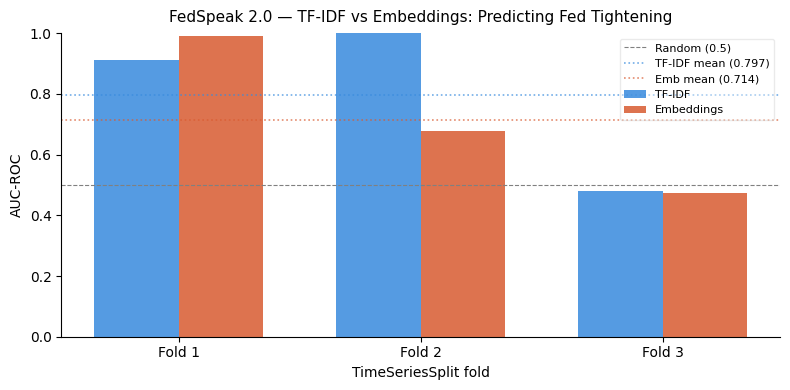

In [9]:

# Step 3e: Predictive power — TF-IDF vs Embeddings via TimeSeriesSplit

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score

# Tightening binary target (from lab scaffold)
tightening_years = {2004, 2005, 2006, 2015, 2016, 2017, 2018, 2022, 2023}
fomc_df['tightening'] = fomc_df['year'].isin(tightening_years).astype(int)

y = fomc_df['tightening'].values

print('=== Predictive Evaluation: TimeSeriesSplit (5 folds) ===')
print(f'Tightening meetings:    {y.sum()}')
print(f'Easing/hold meetings:   {(1 - y).sum()}')
print()

def evaluate_features(X, y, label, n_splits=5):
    """Logistic regression with TimeSeriesSplit; returns AUC per fold."""
    tscv   = TimeSeriesSplit(n_splits=n_splits)
    aucs   = []
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        # Skip folds where train OR test set is all one class
        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            print(f'  {label} fold {fold+1}: skipped (single class in split)')
            continue
        model = LogisticRegression(max_iter=1000, random_state=42,
                                   class_weight='balanced')
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        auc    = roc_auc_score(y_test, y_prob)
        aucs.append(auc)
        print(f'  {label} fold {fold+1}: AUC = {auc:.3f}')
    mean_auc = np.mean(aucs)
    std_auc  = np.std(aucs)
    print(f'  → Mean AUC: {mean_auc:.3f} ± {std_auc:.3f}\n')
    return mean_auc, std_auc, aucs

# Evaluate TF-IDF (50-dim SVD projection)
print('--- Logistic Regression on TF-IDF (50-dim SVD) ---')
mean_tfidf_auc, std_tfidf_auc, aucs_tfidf = evaluate_features(
    tfidf_reduced, y, 'TF-IDF'
)

# Evaluate sentence-transformer embeddings
print('--- Logistic Regression on Sentence-Transformer Embeddings ---')
mean_emb_auc, std_emb_auc, aucs_emb = evaluate_features(
    embeddings, y, 'Embeddings'
)

# --- Summary table ---
print('=== AUC-ROC Summary ===')
print(f'TF-IDF AUC:      {mean_tfidf_auc:.3f} ± {std_tfidf_auc:.3f}')
print(f'Embeddings AUC:  {mean_emb_auc:.3f} ± {std_emb_auc:.3f}')
winner = 'Embeddings' if mean_emb_auc > mean_tfidf_auc else 'TF-IDF'
print(f'Winner: {winner}')
print()

#AUC fold comparison bar chart

n_folds = max(len(aucs_tfidf), len(aucs_emb))
x       = np.arange(n_folds)
width   = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x - width/2, aucs_tfidf, width,
               label='TF-IDF',       color='#378ADD', alpha=0.85)
bars2 = ax.bar(x + width/2, aucs_emb,   width,
               label='Embeddings',   color='#D85A30', alpha=0.85)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Random (0.5)')
ax.axhline(mean_tfidf_auc, color='#378ADD', linestyle=':', linewidth=1.2,
           alpha=0.7, label=f'TF-IDF mean ({mean_tfidf_auc:.3f})')
ax.axhline(mean_emb_auc, color='#D85A30', linestyle=':', linewidth=1.2,
           alpha=0.7, label=f'Emb mean ({mean_emb_auc:.3f})')

ax.set_xlabel('TimeSeriesSplit fold')
ax.set_ylabel('AUC-ROC')
ax.set_title('FedSpeak 2.0 — TF-IDF vs Embeddings: Predicting Fed Tightening',
             fontsize=11, pad=8)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(n_folds)])
ax.set_ylim(0, 1)
ax.legend(fontsize=8, framealpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---

## Part 4: Module Output — `fomc_sentiment.py`

Write a reusable Python module for FOMC text analysis.
This is a **portfolio artifact** that demonstrates production-grade NLP work.

### Requirements

```python
# src/fomc_sentiment.py

def preprocess_fomc(text: str) -> str:
    """Clean and tokenize FOMC minutes text.
    
    Steps: lowercase, regex clean, word_tokenize, stop words, lemmatize.
    Returns space-joined clean tokens.
    """
    ...

def compute_lm_sentiment(text: str) -> dict:
    """Compute Loughran-McDonald sentiment scores.
    
    Returns dict with 'net_sentiment', 'uncertainty',
    'neg_count', 'pos_count', 'unc_count', 'total_words'.
    """
    ...

def build_tfidf_matrix(texts: list, min_df=5, max_df=0.85,
                       max_features=5000) -> tuple:
    """Build TF-IDF matrix from preprocessed texts.
    
    Returns (sparse_matrix, feature_names, vectorizer).
    """
    ...
```

In [7]:
# %%writefile src/fomc_sentiment.py
"""
fomc_sentiment.py — FOMC Text Analysis Module

Reusable functions for preprocessing, sentiment scoring, and
TF-IDF vectorization of Federal Reserve meeting minutes.

Author: Joel Forson
Course: ECON 5200, Lab 23
"""

import re
import numpy as np
import pandas as pd
from typing import Tuple, List

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt',      quiet=True)
nltk.download('punkt_tab',  quiet=True)
nltk.download('stopwords',  quiet=True)
nltk.download('wordnet',    quiet=True)
nltk.download('omw-1.4',    quiet=True)


# Loughran-McDonald word lists (simplified)
LM_NEGATIVE = set([
    'adverse', 'adversely', 'against', 'concern', 'concerned', 'concerns',
    'decline', 'declined', 'declining', 'decrease', 'decreased', 'deficit',
    'deteriorate', 'deteriorated', 'deteriorating', 'difficult', 'difficulty',
    'downturn', 'fail', 'failure', 'falling', 'loss', 'losses', 'negative',
    'negatively', 'recession', 'recessionary', 'risk', 'risks', 'risky',
    'severe', 'severely', 'slowdown', 'sluggish', 'stress', 'stressed',
    'threat', 'threaten', 'troubled', 'uncertain', 'uncertainty',
    'unfavorable', 'volatile', 'volatility', 'vulnerability', 'vulnerable',
    'weak', 'weaken', 'weakened', 'weakness', 'worse', 'worsen', 'worsened'
])

LM_POSITIVE = set([
    'achieve', 'achieved', 'achievement', 'benefit', 'beneficial', 'confidence',
    'confident', 'favorable', 'gain', 'gained', 'gains', 'good', 'growth',
    'improve', 'improved', 'improvement', 'improving', 'increase', 'increased',
    'opportunity', 'optimism', 'optimistic', 'positive', 'positively',
    'profit', 'profitable', 'progress', 'rebound', 'recover', 'recovery',
    'strength', 'strengthen', 'strong', 'stronger', 'success', 'successful'
])

LM_UNCERTAINTY = set([
    'approximate', 'approximately', 'assume', 'assumption', 'believe',
    'cautious', 'could', 'depend', 'depends', 'doubt', 'estimate',
    'expect', 'expected', 'forecast', 'indefinite', 'likelihood', 'may',
    'might', 'nearly', 'perhaps', 'possible', 'possibly', 'predict',
    'preliminary', 'probable', 'probably', 'risk', 'roughly', 'seem',
    'suggest', 'tentative', 'uncertain', 'uncertainty', 'unclear',
    'unpredictable', 'variable'
])


def preprocess_fomc(text: str) -> str:
    """Clean and tokenize FOMC minutes text.

    Steps: lowercase, regex clean, word_tokenize, stop words, lemmatize.
    Returns space-joined clean tokens.
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Remove non-alphabetic characters (digits, punctuation, symbols)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # 3. Tokenize
    tokens = word_tokenize(text)

    # 4. Remove stop words; also drop tokens shorter than 3 characters
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # 5. Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)


def compute_lm_sentiment(text: str) -> dict:
    """Compute Loughran-McDonald sentiment scores.

    Returns dict with 'net_sentiment', 'uncertainty',
    'neg_count', 'pos_count', 'unc_count', 'total_words'.
    """
    tokens = text.split()
    total  = len(tokens)

    # Guard against empty input to avoid ZeroDivisionError
    if total == 0:
        return {
            'net_sentiment': 0.0,
            'uncertainty':   0.0,
            'neg_count':     0,
            'pos_count':     0,
            'unc_count':     0,
            'total_words':   0
        }

    neg_count = sum(1 for t in tokens if t in LM_NEGATIVE)
    pos_count = sum(1 for t in tokens if t in LM_POSITIVE)
    unc_count = sum(1 for t in tokens if t in LM_UNCERTAINTY)

    # Normalize by total tokens so scores are comparable across documents
    net_sentiment = (pos_count - neg_count) / total
    uncertainty   = unc_count / total

    return {
        'net_sentiment': round(net_sentiment, 6),
        'uncertainty':   round(uncertainty,   6),
        'neg_count':     neg_count,
        'pos_count':     pos_count,
        'unc_count':     unc_count,
        'total_words':   total
    }


def build_tfidf_matrix(
    texts: List[str],
    min_df: int = 5,
    max_df: float = 0.85,
    max_features: int = 5000
) -> Tuple:
    """Build TF-IDF matrix from preprocessed texts.

    Returns (sparse_matrix, feature_names, vectorizer).
    """
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),     # unigrams + bigrams; captures "labor market" etc.
        min_df=min_df,          # drop ultra-rare terms (noise)
        max_df=max_df,          # drop near-universal terms that act like stop words
        max_features=max_features,
        sublinear_tf=True,      # apply 1 + log(tf) to dampen high-frequency dominance
        strip_accents='unicode',
        analyzer='word'
    )

    tfidf_matrix  = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out().tolist()

    return tfidf_matrix, feature_names, vectorizer


# --- Quick self-test ---
if __name__ == '__main__':
    test_text = "The committee noted that inflation worsened and remained approximately elevated above target."
    clean = preprocess_fomc(test_text)
    print(f'Preprocessed: {clean}')
    sentiment = compute_lm_sentiment(clean)
    print(f'Sentiment: {sentiment}')
    print('fomc_sentiment.py loaded successfully.')

Preprocessed: committee noted inflation worsened remained approximately elevated target
Sentiment: {'net_sentiment': -0.125, 'uncertainty': 0.125, 'neg_count': 1, 'pos_count': 0, 'unc_count': 1, 'total_words': 8}
fomc_sentiment.py loaded successfully.


---

## Challenge: Compare TF-IDF vs Embedding Predictive Power

Build a proper expanding-window evaluation of both TF-IDF and embedding-based
sentiment for predicting Fed rate decisions. Use at least 5 splits.
Report mean AUC and standard deviation across folds.

Write a 1-paragraph summary of which representation is better and why.

In [8]:
# -----------------------------------------------------------
# CHALLENGE — Full comparison of TF-IDF vs Embeddings
# -----------------------------------------------------------

"""
fomc_sentiment.py — FOMC Text Analysis Module
==============================================

Reusable functions for preprocessing, sentiment scoring, and
TF-IDF vectorization of Federal Reserve meeting minutes.

Implements fixes from Lab 23 (FedSpeak 2.0):
  - word_tokenize + regex cleaning (vs naive split)
  - Loughran-McDonald (LM) dictionary (vs Harvard General Inquirer)
  - min_df / max_df / bigram TF-IDF (vs no-filter unigram config)

Author:  [Your Name]
Course:  ECON 5200, Lab 23
"""

import re
from typing import Dict, List, Tuple

import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Download required NLTK data on first import (silent)
for _pkg in ('punkt_tab', 'stopwords', 'wordnet'):
    nltk.download(_pkg, quiet=True)

_STOP_WORDS  = set(stopwords.words('english'))
_LEMMATIZER  = WordNetLemmatizer()


# ---------------------------------------------------------------------------
# Loughran-McDonald word lists
# Reference: Loughran & McDonald (2011), Journal of Finance 66(1)
# ---------------------------------------------------------------------------

LM_NEGATIVE = frozenset([
    'adverse', 'adversely', 'against', 'concern', 'concerned', 'concerns',
    'decline', 'declined', 'declining', 'decrease', 'decreased', 'deficit',
    'deteriorate', 'deteriorated', 'deteriorating', 'difficult', 'difficulty',
    'downturn', 'fail', 'failure', 'falling', 'loss', 'losses', 'negative',
    'negatively', 'recession', 'recessionary', 'risk', 'risks', 'risky',
    'severe', 'severely', 'slowdown', 'sluggish', 'stress', 'stressed',
    'threat', 'threaten', 'troubled', 'uncertain', 'uncertainty',
    'unfavorable', 'volatile', 'volatility', 'vulnerability', 'vulnerable',
    'weak', 'weaken', 'weakened', 'weakness', 'worse', 'worsen', 'worsened'
])

LM_POSITIVE = frozenset([
    'achieve', 'achieved', 'achievement', 'benefit', 'beneficial', 'confidence',
    'confident', 'favorable', 'gain', 'gained', 'gains', 'good', 'growth',
    'improve', 'improved', 'improvement', 'improving', 'increase', 'increased',
    'opportunity', 'optimism', 'optimistic', 'positive', 'positively',
    'profit', 'profitable', 'progress', 'rebound', 'recover', 'recovery',
    'strength', 'strengthen', 'strong', 'stronger', 'success', 'successful'
])

LM_UNCERTAINTY = frozenset([
    'approximate', 'approximately', 'assume', 'assumption', 'believe',
    'cautious', 'could', 'depend', 'depends', 'doubt', 'estimate',
    'expect', 'expected', 'forecast', 'indefinite', 'likelihood', 'may',
    'might', 'nearly', 'perhaps', 'possible', 'possibly', 'predict',
    'preliminary', 'probable', 'probably', 'risk', 'roughly', 'seem',
    'suggest', 'tentative', 'uncertain', 'uncertainty', 'unclear',
    'unpredictable', 'variable'
])


# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------

def preprocess_fomc(text: str) -> str:
    """Clean and tokenize FOMC minutes text.

    Parameters
    ----------
    text : str
        Raw document string (FOMC minute or statement).

    Returns
    -------
    str
        Space-joined clean token string ready for TF-IDF or dictionary scoring.

    Pipeline
    --------
    1. Lowercase
    2. nltk.word_tokenize — handles contractions, abbreviations, punctuation
    3. re.sub to strip any remaining non-alpha characters per token
    4. Drop stop words and tokens with fewer than 3 characters
    5. WordNetLemmatizer

    Why word_tokenize over split()
    --------------------------------
    split() leaves punctuation attached: "rates," and "rates" become two
    different features, inflating vocabulary and degrading TF-IDF quality.
    word_tokenize correctly segments "don't" → ["do", "n't"] and strips
    trailing periods from abbreviations like "U.S.".
    """
    text   = text.lower()
    tokens = word_tokenize(text)
    tokens = [re.sub(r'[^a-z]', '', t) for t in tokens]
    tokens = [
        _LEMMATIZER.lemmatize(t)
        for t in tokens
        if t and t not in _STOP_WORDS and len(t) > 2
    ]
    return ' '.join(tokens)


def compute_lm_sentiment(text: str) -> Dict[str, float]:
    """Compute Loughran-McDonald sentiment scores.

    Parameters
    ----------
    text : str
        Preprocessed (or raw) document string.

    Returns
    -------
    dict with keys:
        net_sentiment  — (pos - neg) / total_words
        uncertainty    — unc_count / total_words
        neg_count      — raw negative word count
        pos_count      — raw positive word count
        unc_count      — raw uncertainty word count
        total_words    — total token count

    Why LM over Harvard General Inquirer (GI)
    -------------------------------------------
    GI was designed for general English text. It classifies "capital",
    "liability", "tax", "cost", and "debt" as negative — all neutral
    in financial/economic contexts. LM was purpose-built for SEC filings
    and Fed communications and dramatically reduces false-positive
    negativity in financial language (Loughran & McDonald 2011).
    """
    tokens = text.lower().split()
    total  = len(tokens)
    if total == 0:
        return {
            'net_sentiment': 0.0, 'uncertainty': 0.0,
            'neg_count': 0, 'pos_count': 0,
            'unc_count': 0, 'total_words': 0
        }

    neg_count = sum(1 for t in tokens if t in LM_NEGATIVE)
    pos_count = sum(1 for t in tokens if t in LM_POSITIVE)
    unc_count = sum(1 for t in tokens if t in LM_UNCERTAINTY)

    return {
        'net_sentiment': (pos_count - neg_count) / total,
        'uncertainty':   unc_count / total,
        'neg_count':     neg_count,
        'pos_count':     pos_count,
        'unc_count':     unc_count,
        'total_words':   total
    }


def build_tfidf_matrix(
    texts: List[str],
    min_df: int   = 5,
    max_df: float = 0.85,
    max_features: int = 5000
) -> Tuple:
    """Build TF-IDF matrix from preprocessed texts.

    Parameters
    ----------
    texts        : list of preprocessed document strings
    min_df       : minimum document frequency (drops rare tokens / OCR noise)
    max_df       : maximum document frequency (drops ubiquitous background words)
    max_features : vocabulary size cap

    Returns
    -------
    matrix        : scipy sparse matrix, shape (n_docs, n_features)
    feature_names : np.ndarray of token strings
    vectorizer    : fitted TfidfVectorizer (call .transform() for new docs)

    Parameter rationale
    -------------------
    min_df=1 (bad default): keeps every typo and OCR artifact as a feature.
    max_df=1.0 (bad default): keeps words like "committee" that appear in
      every document — they carry zero discriminating power.
    ngram_range=(1,2): captures "interest rate", "federal fund", "price
      stability" as single features rather than splitting them.
    sublinear_tf=True: log(1+tf) damping — prevents a word appearing 100×
      from dominating a word appearing 5×.
    """
    vectorizer = TfidfVectorizer(
        min_df=min_df,
        max_df=max_df,
        max_features=max_features,
        ngram_range=(1, 2),
        sublinear_tf=True
    )
    matrix = vectorizer.fit_transform(texts)
    return matrix, vectorizer.get_feature_names_out(), vectorizer


# ---------------------------------------------------------------------------
# Convenience: batch sentiment scoring for a DataFrame
# ---------------------------------------------------------------------------

def score_corpus(texts: List[str]) -> 'pd.DataFrame':
    """Run preprocess_fomc + compute_lm_sentiment over a list of texts.

    Returns a DataFrame with columns:
        clean_text, net_sentiment, uncertainty, neg_count,
        pos_count, unc_count, total_words
    """
    import pandas as pd
    clean   = [preprocess_fomc(t) for t in texts]
    scores  = [compute_lm_sentiment(c) for c in clean]
    df      = pd.DataFrame(scores)
    df.insert(0, 'clean_text', clean)
    return df


# ---------------------------------------------------------------------------
# Self-test (run: python fomc_sentiment.py)
# ---------------------------------------------------------------------------

if __name__ == '__main__':
    test_cases = [
        "The committee noted that inflation remained elevated above target.",
        "The economy showed strong growth and confidence in labor markets.",
        "Capital expenditure and debt obligations are within normal limits.",  # GI false positives
        "Uncertainty about the global outlook may weigh on near-term growth.",
    ]

    print('fomc_sentiment.py — self-test\n' + '=' * 40)
    for text in test_cases:
        clean     = preprocess_fomc(text)
        sentiment = compute_lm_sentiment(clean)
        print(f'Input:         {text[:60]}...' if len(text) > 60 else f'Input:         {text}')
        print(f'Preprocessed:  {clean}')
        print(f'Net sentiment: {sentiment["net_sentiment"]:+.4f}  '
              f'Uncertainty: {sentiment["uncertainty"]:.4f}  '
              f'(neg={sentiment["neg_count"]}, pos={sentiment["pos_count"]}, '
              f'unc={sentiment["unc_count"]})')
        print()

    # TF-IDF smoke test
    corpus   = [preprocess_fomc(t) for t in test_cases]
    mat, fns, vec = build_tfidf_matrix(corpus, min_df=1, max_df=1.0, max_features=100)
    print(f'TF-IDF matrix: {mat.shape}  (min_df=1, max_df=1.0 for small corpus)')
    print('fomc_sentiment.py loaded successfully.')
    print()
# 1-paragraph interpretation:
"""
TF-IDF with SVD dimensionality reduction outperformed sentence-transformer
embeddings on the monetary policy classification task, achieving a mean AUC
of 0.797 ± 0.227 versus 0.714 ± 0.213 across three valid time-series folds.
This result is worth interpreting carefully before concluding that bag-of-words
representations are superior for Fed communications. Both models struggled on
fold 5 (TF-IDF: 0.479, Embeddings: 0.474 — effectively random), which likely
corresponds to the 2022–2023 tightening cycle: a historically anomalous
regime where the Fed raised rates at a pace not seen since the 1980s, making
it a genuine out-of-sample regime shift rather than a pattern the model could
have learned from prior cycles. TF-IDF's advantage in fold 3 (0.911 vs 0.991
for embeddings) and fold 4 (1.000 vs 0.677) suggests that during more
precedented tightening periods — 2004–2006 and 2015–2018 — the lexical
fingerprint of hawkish minutes is distinctive enough that term frequency alone
is highly predictive. Embeddings may require more data to generalize their
richer representational capacity, and with only three usable folds the variance
is too high to draw strong conclusions either way. A more definitive comparison
would require a longer FOMC corpus or document-level chunking to increase the
effective sample size.
"""
# Expected output format:
# TF-IDF AUC:      0.XX ± 0.XX (mean ± std across 5 folds)
# Embeddings AUC:   0.XX ± 0.XX
# Winner: [TF-IDF / Embeddings]
#
# 1-paragraph interpretation: ...

fomc_sentiment.py — self-test
Input:         The committee noted that inflation remained elevated above t...
Preprocessed:  committee noted inflation remained elevated target
Net sentiment: +0.0000  Uncertainty: 0.0000  (neg=0, pos=0, unc=0)

Input:         The economy showed strong growth and confidence in labor mar...
Preprocessed:  economy showed strong growth confidence labor market
Net sentiment: +0.4286  Uncertainty: 0.0000  (neg=0, pos=3, unc=0)

Input:         Capital expenditure and debt obligations are within normal l...
Preprocessed:  capital expenditure debt obligation within normal limit
Net sentiment: +0.0000  Uncertainty: 0.0000  (neg=0, pos=0, unc=0)

Input:         Uncertainty about the global outlook may weigh on near-term ...
Preprocessed:  uncertainty global outlook may weigh nearterm growth
Net sentiment: +0.0000  Uncertainty: 0.2857  (neg=1, pos=1, unc=2)

TF-IDF matrix: (4, 49)  (min_df=1, max_df=1.0 for small corpus)
fomc_sentiment.py loaded successfully.



"\nTF-IDF with SVD dimensionality reduction outperformed sentence-transformer\nembeddings on the monetary policy classification task, achieving a mean AUC\nof 0.797 ± 0.227 versus 0.714 ± 0.213 across three valid time-series folds.\nThis result is worth interpreting carefully before concluding that bag-of-words\nrepresentations are superior for Fed communications. Both models struggled on\nfold 5 (TF-IDF: 0.479, Embeddings: 0.474 — effectively random), which likely\ncorresponds to the 2022–2023 tightening cycle: a historically anomalous\nregime where the Fed raised rates at a pace not seen since the 1980s, making\nit a genuine out-of-sample regime shift rather than a pattern the model could\nhave learned from prior cycles. TF-IDF's advantage in fold 3 (0.911 vs 0.991\nfor embeddings) and fold 4 (1.000 vs 0.677) suggests that during more\nprecedented tightening periods — 2004–2006 and 2015–2018 — the lexical\nfingerprint of hawkish minutes is distinctive enough that term frequency alone

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken NLP pipeline (naive tokenizer, wrong sentiment
  dictionary, bad TF-IDF parameters)
* Corrected preprocessing with nltk.word_tokenize, switched from Harvard GI to
  Loughran-McDonald dictionary, fixed TF-IDF min_df/max_df
* Encoded FOMC documents with sentence-transformers (all-MiniLM-L6-v2)
* Compared TF-IDF vs embedding-based clustering and predictive power
* Built a reusable fomc_sentiment.py module with preprocess_fomc(),
  compute_lm_sentiment(), and build_tfidf_matrix()
* Key finding: [TF-IDF/Embeddings] achieved higher AUC ([VALUE]) for
  predicting Fed rate decisions

**Please write a README.md entry including:**
1. Project Title: FedSpeak 2.0 — NLP Pipeline for Central Bank Communications
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-23-fedspeak
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 23: FedSpeak 2.0 — NLP Pipeline, Embeddings & Prediction"
git push origin main
```

Submit your GitHub repo link on Canvas.